
# BIOINF 580 — Lab 1
### 09/16/2026
### GSI: Morgen Henry


## Contents
0. [Setting Up the Environment](#0.-Setting-Up-the-Environment-(Highly-Recommended))
0. [Markdown Primer](#Markdown-Primer-(Quick-Reference))
1. [Python Basics](#1.-Python-Basics)
2. [Vectors (1D NumPy Arrays)](#2.-Vectors-(1D-NumPy-Arrays))
3. [Matrices (2D NumPy Arrays)](#3.-Matrices-(2D-NumPy-Arrays))
4. [Indexing & Slicing](#4.-Indexing-&-Slicing-(0-indexed))
5. [Functions, Loops, and Conditionals](#5.-Functions,-Loops,-and-Conditionals)
6. [Saving & Loading Data](#6.-Saving-&-Loading-Data)
7. [Plotting with Matplotlib](#7.-Plotting-with-Matplotlib)
8. [Fourier Transform with Python](#8.-Fourier-Transform-with-Python-(NumPy-&-SciPy))
9. [Using AI Tools to Assist with Coding](#9.-Using-AI-Tools-to-Assist-with-Coding)

**Tip:** in Jupyter, click a section header's "¶" link or use the Table of Contents extension in the sidebar to jump around quickly.


## 0. Setting Up the Environment (Highly Recommended)

We recommend creating a dedicated conda environment for this course.  
Open a terminal (or Anaconda Prompt on Windows) and run the following commands:

```bash
# Create a new environment named 'bioinf580' with Python 3.11
conda create -n bioinf580 python=3.11

# Activate the environment
conda activate bioinf580

# Install required packages
conda install pandas numpy scipy pywavelets matplotlib

# Install IPython kernel support
conda install ipykernel -y

# Register this environment as a Jupyter kernel
python -m ipykernel install --user --name=bioinf580 --display-name="Python (bioinf580)"
```

After running these commands, make sure to select the **bioinf580** kernel for this notebook.


### Test Your Setup ✅

Run the following cell to make sure your environment is working properly.

It should:
1. Print your Python version.
2. Import `pandas`, `numpy`, `scipy`, `pywt`, and `matplotlib` without errors.
3. Show a simple sine wave plot.


In [2]:

import sys
import pandas as pd
import numpy as np
import scipy
import pywt
import matplotlib

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("SciPy version:", scipy.__version__)
print("PyWavelets version:", pywt.__version__)
print("Matplotlib version:", matplotlib.__version__)


Python version: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:01) [Clang 18.1.8 ]
Pandas version: 2.3.3
NumPy version: 1.26.4
SciPy version: 1.16.2
PyWavelets version: 1.8.0
Matplotlib version: 3.10.6



## Markdown Primer (Quick Reference)
- Use **bold**, *italic*, and `code` formatting.
- Create lists with `-` or `1.`
- Add equations with LaTeX, e.g., $y=\sin(2\pi f t)$
- Insert code cells below with `+ Code` and Markdown cells with `+ Markdown`.


## 1. Python Basics

### 1.1 Comments and Printing

- Use `#` to add comments in Python. Anything after `#` is ignored by the interpreter.  
- Use `print()` to display values. In Jupyter, the **value of the last expression** in a cell is displayed automatically, even without `print()`.

In [3]:

# This is a comment (ignored by Python)

a = 2          # assign the value 2 to variable 'a'
print(a)       # explicitly print 'a' → will show 2

b = 4          # assign the value 4 to variable 'b'
b              # The LAST expression in a cell is displayed automatically → will show 4


2


4


### 1.2 Variables and Basic Data Types

Python has several built-in data types. The most common ones:

- **int** → integer numbers  
- **float** → decimal numbers  
- **str** → strings (text)  
- **bool** → boolean values (True/False)

Use `type()` to check the type of a variable.

In [4]:

x = 5        # int
y = 3.14     # float
s = "hello"  # str
b = True     # bool

print(type(x), type(y), type(s), type(b))


<class 'int'> <class 'float'> <class 'str'> <class 'bool'>



### 1.2 Sequences

Python provides several sequence types:

- **list** → ordered, mutable sequence  
- **tuple** → ordered, immutable sequence


In [5]:

# List (mutable)
my_list = [1, 2, 3, 4]
my_list.append(5)        # add an element
print("List:", my_list)

# Tuple (immutable)
my_tuple = (1, 2, 3, 4)
print("Tuple:", my_tuple)


List: [1, 2, 3, 4, 5]
Tuple: (1, 2, 3, 4)



### 1.3 Dictionaries

Dictionaries (`dict`) store data as **key → value** pairs.


In [6]:

student = {
    "name": "Alice",
    "age": 21,
    "major": "Bioinformatics"
}

print("Student name:", student["name"])
print("Student age:", student["age"])

# Add a new key-value pair
student["GPA"] = 3.9
print("Updated dictionary:", student)

# List all keys
print("Keys:", student.keys())


Student name: Alice
Student age: 21
Updated dictionary: {'name': 'Alice', 'age': 21, 'major': 'Bioinformatics', 'GPA': 3.9}
Keys: dict_keys(['name', 'age', 'major', 'GPA'])


### 1.4 Basic Math Operations

In [7]:

a = 2
b = 4

print(a + b)   # addition
print(b - a)   # subtraction
print(a * b)   # multiplication
print(a / b)   # division (float)
print(a // b)  # integer division
print(a ** b)  # power


6
2
8
0.5
0
16



### 1.5 "Help" in Python
Use `help(function)` or `?function` in Jupyter to see docstrings.


In [8]:

help(len)   # try also: ?len in a Jupyter cell


Help on built-in function len in module builtins:

len(obj, /)
    Return the number of items in a container.




## 2. Vectors (1D NumPy Arrays)

NumPy provides arrays, which are like **lists** but with two important differences:
- All elements are usually of the **same data type** (e.g., all floats).  
- They support **vectorized math** (fast operations on whole arrays).  



### 2.1 Creating vectors

You can create vectors in several ways:
- From a Python list using `np.array`
- Using `np.arange(start, stop, step)` for sequences
- Using `np.linspace(start, stop, num_points)` for evenly spaced values
- Using special constructors like `np.zeros`, `np.ones`, `np.full`, `np.random.rand`


In [9]:

import numpy as np

a1 = np.array([1,2,3,4,5])          # from list
a2 = np.arange(0, 11)               # 0..10
a3 = np.arange(0, 101, 5)           # 0, 5, 10, ... 100
a4 = np.linspace(0, 1, 5)           # 5 points between 0 and 1
a5 = np.zeros(5)                    # 5 zeros
a6 = np.ones(5)                     # 5 ones
a7 = np.full(5, 7)                  # 5 sevens
a8 = np.random.rand(5)              # 5 random numbers in [0,1)

a1, a2, a3[:10], a4, a5, a6, a7, a8


(array([1, 2, 3, 4, 5]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
 array([0., 0., 0., 0., 0.]),
 array([1., 1., 1., 1., 1.]),
 array([7, 7, 7, 7, 7]),
 array([0.44546188, 0.97313209, 0.65675615, 0.29480553, 0.80758921]))


### 2.2 Elementwise Operations

NumPy applies arithmetic **elementwise** by default.


In [10]:

a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

print("a + b =", a + b)   # elementwise addition
print("a - b =", a - b)   # elementwise subtraction
print("a * b =", a * b)   # elementwise multiplication
print("a / b =", a / b)   # elementwise division
print("a ** 2 =", a ** 2) # elementwise power


a + b = [11 22 33 44 55]
a - b = [ -9 -18 -27 -36 -45]
a * b = [ 10  40  90 160 250]
a / b = [0.1 0.1 0.1 0.1 0.1]
a ** 2 = [ 1  4  9 16 25]


### Try it yourself
Create a NumPy vector `v` containing the numbers 1 through 10 using `np.arange`.
Then compute and print:
1. `v` squared (elementwise)
2. The mean of `v` (`v.mean()`)
3. Only the even-indexed elements of `v` (hint: slicing with a step, `v[::2]`)


In [11]:
# Your code here



## 3. Matrices (2D NumPy Arrays)



### 3.1 Creating matrices
You can create 2D arrays (“matrices”) from nested Python lists or with NumPy constructors.


In [12]:

import numpy as np

# From nested lists
m1 = np.array([[1, 2, 3],
               [4, 5, 6],
               [7, 8, -1]])

# Constructors
Z = np.zeros((2, 3))        # 2x3 zeros
O = np.ones((3, 2))         # 3x2 ones
F = np.full((2, 2), 7)      # 2x2 filled with 7
R = np.random.rand(3, 4)    # 3x4 uniform random in [0,1)
I = np.eye(3)               # 3x3 identity

m1, Z, O, F, R, I


(array([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8, -1]]),
 array([[0., 0., 0.],
        [0., 0., 0.]]),
 array([[1., 1.],
        [1., 1.],
        [1., 1.]]),
 array([[7, 7],
        [7, 7]]),
 array([[0.83098199, 0.55787774, 0.71708499, 0.62985372],
        [0.70164196, 0.01229563, 0.54441697, 0.63271219],
        [0.36337257, 0.81339488, 0.42821528, 0.43435094]]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]))


### 3.2 Matrix operations (`+`, `-`, `@`, `.T`)
- `+`, `-` → elementwise add/subtract (shapes must match)
- `*` → elementwise multiply  
- `@` or `np.matmul(A, B)` → **matrix multiplication**
- `.T` → transpose


In [13]:

A = np.array([[1, 2, 3],
              [0, 1, 4]])
B = np.array([[2, 0],
              [1, 2],
              [3, 1]])

# Elementwise operations (need same shape)
C = np.array([[10, 10, 10],
              [10, 10, 10]])
print("A + C =\n", A + C)
print("A - C =\n", A - C)
print("A * C (elementwise) =\n", A * C)

# Matrix multiplication (inner dimensions must match)
print("A @ B =\n", A @ B)              # 2x3 @ 3x2 -> 2x2
print("np.matmul(A, B) =\n", np.matmul(A, B))

# Transpose
print("A.T =\n", A.T)


A + C =
 [[11 12 13]
 [10 11 14]]
A - C =
 [[ -9  -8  -7]
 [-10  -9  -6]]
A * C (elementwise) =
 [[10 20 30]
 [ 0 10 40]]
A @ B =
 [[13  7]
 [13  6]]
np.matmul(A, B) =
 [[13  7]
 [13  6]]
A.T =
 [[1 0]
 [2 1]
 [3 4]]



### 3.3 Shape, size, number of elements
- `.shape` → tuple of dimensions `(rows, cols)`  
- `.ndim` → number of dimensions  
- `.size` → total number of elements (rows × cols)


In [14]:

print("m1 =\n", m1)
print("shape:", m1.shape)   # (3, 3)
print("ndim:", m1.ndim)     # 2
print("size:", m1.size)     # 9

# Row/column counts from shape
rows, cols = m1.shape
print("rows:", rows, "cols:", cols)


m1 =
 [[ 1  2  3]
 [ 4  5  6]
 [ 7  8 -1]]
shape: (3, 3)
ndim: 2
size: 9
rows: 3 cols: 3



## (Optional) Tensors (N-Dimensional Arrays)

NumPy arrays can have more than 2 dimensions.  
- **1D** → Vector (shape `(n,)`)  
- **2D** → Matrix (shape `(m, n)`)  
- **3D** → Stack of matrices (shape `(d, m, n)`)  
- **4D+** → Often used in machine learning (e.g., batches of images, multi-channel data)

These higher-dimensional arrays are usually called **tensors**.


In [15]:

import numpy as np

# 1D vector
v = np.array([1, 2, 3])
print("Vector shape:", v.shape)

# 2D matrix
m = np.array([[1, 2], [3, 4]])
print("Matrix shape:", m.shape)

# 3D array (2 matrices of 2x2)
arr3d = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])
print("3D array shape:", arr3d.shape)

# 4D array (10 samples, 3 channels, 28x28 images)
arr4d = np.random.rand(10, 3, 28, 28)
print("4D array shape:", arr4d.shape)


Vector shape: (3,)
Matrix shape: (2, 2)
3D array shape: (2, 2, 2)
4D array shape: (10, 3, 28, 28)


### Try it yourself
Create a 3x3 matrix `M` of your choice (any numbers).
1. Compute `M @ M.T` (matrix times its own transpose).
2. Print the shape of the result. Why is it always square, no matter what `M` looks like?


In [16]:
# Your code here



## 4. Indexing & Slicing (0-indexed)

### 4.1 Indexing & slicing in 1D (vectors)

- Python arrays are **0-indexed** → the first element is at position `0`.  
- Use `array[start:stop]` for slicing; the `stop` index is **excluded**.  
- Use `:` to select an entire row or column.  
- Negative indices count from the end (`-1` = last element).  


In [17]:

import numpy as np

a = np.array([10, 20, 30, 40, 50])

print("a =", a)
print("a[0] =", a[0])      # first element
print("a[1:4] =", a[1:4])  # slice from index 1 to 3 (stop=4 excluded)
print("a[:3] =", a[:3])    # first three elements
print("a[3:] =", a[3:])    # elements from index 3 to end
print("a[-1] =", a[-1])    # last element
print("a[-2:] =", a[-2:])  # last two elements


a = [10 20 30 40 50]
a[0] = 10
a[1:4] = [20 30 40]
a[:3] = [10 20 30]
a[3:] = [40 50]
a[-1] = 50
a[-2:] = [40 50]



### 4.2 Indexing & slicing in 2D (matrices)
- Use `[row, col]` for a single element.  
- Use `:` to select full rows/columns.  


In [18]:

m = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

print("m =\n", m)
print("m[0,0] =", m[0,0])     # first row, first column
print("m[1,:] =", m[1,:])     # entire second row
print("m[:,2] =", m[:,2])     # entire third column
print("m[0:2, 0:2] =\n", m[0:2, 0:2])  # top-left 2x2 submatrix


m =
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
m[0,0] = 1
m[1,:] = [4 5 6]
m[:,2] = [3 6 9]
m[0:2, 0:2] =
 [[1 2]
 [4 5]]



## 5. Functions, Loops, and Conditionals

Python provides basic control flow structures for programming logic.

### 5.1 Defining Functions with `def`

A function groups code into a reusable block.  
Use the `def` keyword, list inputs in parentheses, and use `return` to send back a result.


In [19]:

# Simple function with one input
def double(x):
    return 2 * x

print(double(5))

# Function with multiple outputs
def add_and_multiply(a, b):
    return a + b, a * b

s, p = add_and_multiply(2, 3)
print("Sum:", s, "Product:", p)


10
Sum: 5 Product: 6



### 5.2 For Loops with `range` and Iteration

Use a `for` loop to repeat code.  
- `range(n)` gives integers from 0 up to n-1.  
- You can also loop directly over arrays or lists.


In [20]:

# Loop using range
for i in range(5):
    print("i =", i)

# Loop over elements in a list
my_list = [10, 20, 30]
for value in my_list:
    print("Value:", value)

# Loop over a NumPy array
import numpy as np
arr = np.array([1, 2, 3, 4])
for element in arr:
    print("Array element:", element)


i = 0
i = 1
i = 2
i = 3
i = 4
Value: 10
Value: 20
Value: 30
Array element: 1
Array element: 2
Array element: 3
Array element: 4



### 5.3 If / Else Statements for Branching

Use `if`, `elif`, and `else` to make decisions.


In [21]:

x = -3

if x > 0:
    print("Positive")
elif x == 0:
    print("Zero")
else:
    print("Negative")

# Inside a loop
for i in range(-2, 3):
    if i % 2 == 0:   # remainder
        print(i, "is even")
    else:
        print(i, "is odd")


Negative
-2 is even
-1 is odd
0 is even
1 is odd
2 is even


### Try it yourself
Write a function `is_prime(n)` that returns `True` if `n` is a prime number and `False` otherwise.
Then use a `for` loop to print all prime numbers between 2 and 30.

*(This is a great task to try solving on your own first, then compare with what an AI assistant suggests - see Section 10 at the end of this notebook.)*


In [22]:
# Your code here
def is_prime(n):
    pass



## 6. Saving & Loading Data

Python offers multiple ways to save and load data.  
Two common formats are:

- **CSV (comma-separated values):** a plain text file where numbers are stored in rows and columns separated by commas.  
- **NumPy `.npz`:** a special NumPy archive file that can hold multiple arrays inside one file.



### 6.1 CSV Files

CSV files can be opened in Excel, text editors, or Python.  
We will use **pandas** to save and load them.


In [23]:

import numpy as np
import pandas as pd

# Example: create a 5x5 table of random data
data = np.random.randn(5,5)

# --- Save to CSV ---
pd.DataFrame(data).to_csv("data.csv", index=False)

# --- Load from CSV ---
df = pd.read_csv("data.csv")
print("CSV loaded shape:", df.shape)
df.head()


CSV loaded shape: (5, 5)


,0,1,2,3,4
0,-0.710853,-2.458727,-1.315181,1.070491,0.458968
1,-1.441056,3.069404,1.130836,-2.113186,0.019168
2,-0.340602,-0.822016,-0.672362,-0.330272,-0.511660
3,0.184505,-0.277366,0.563097,-0.109960,0.450257
4,-0.367686,0.929724,-0.531942,-0.131493,1.371415



### 6.2 NumPy `.npz` Files

NumPy can save multiple arrays into a single `.npz` file.  
- Inside, the data is stored in a **dictionary-like format** (keys → arrays).  
- You can access arrays by their keys after loading.


In [24]:

import numpy as np

data = np.random.randn(5,5)   # a 5x5 table of random data
t = np.linspace(0,1,101)
x = 2*np.pi*t
y = np.sin(x)

# --- Save multiple arrays in one file ---
np.savez("data.npz", data=data, t=t, x=x, y=y)

# --- Load them back ---
loaded = np.load("data.npz")
print("Keys in npz file:", list(loaded.keys()))  # dict-like
print("data shape from npz:", loaded["data"].shape)


Keys in npz file: ['data', 't', 'x', 'y']
data shape from npz: (5, 5)



## 7. Plotting with Matplotlib

### 7.1 Basic Plots

Matplotlib is the standard Python library for plotting.  
- `plt.plot()` → line plots  
- `plt.scatter()` or `plt.plot(..., 'o')` → scatter plots  
- `plt.bar()` → bar charts  
- `plt.hist()` → histograms  

Always add **titles, labels, and legends** for clarity.


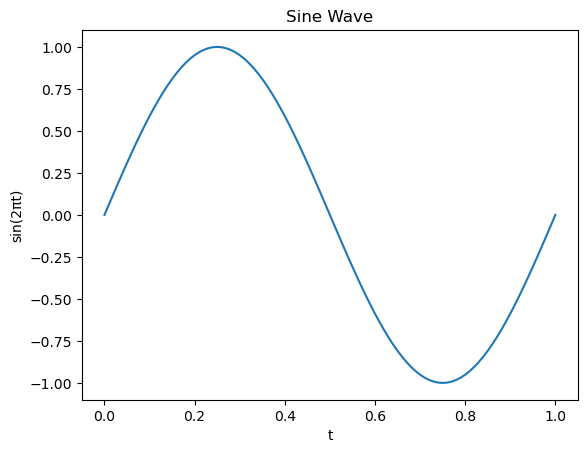

In [25]:

import numpy as np
import matplotlib.pyplot as plt

# Create data for a sine wave
t = np.linspace(0,1,101)       # 0..1 inclusive, 101 points
x = 2*np.pi*t
y = np.sin(x)

# Basic line plot
plt.figure()
plt.plot(t, y)
plt.title("Sine Wave")
plt.xlabel("t")
plt.ylabel("sin(2πt)")
plt.show()


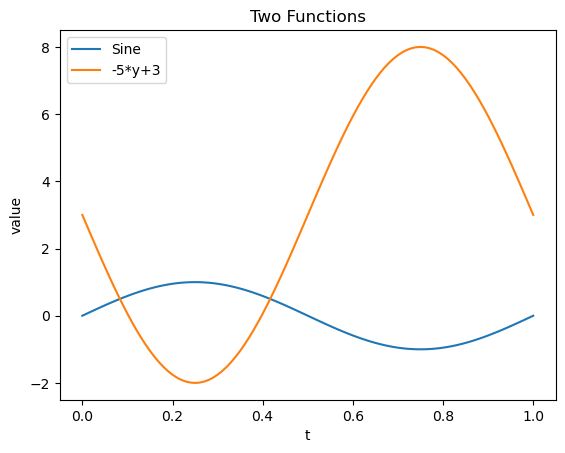

In [26]:

# Two curves on the same plot
plt.figure()
plt.plot(t, y)
plt.plot(t, -5*y+3)
plt.legend(["Sine", "-5*y+3"])
plt.title("Two Functions")
plt.xlabel("t")
plt.ylabel("value")
plt.show()


### 7.2 Subplots

You can combine multiple plots into a grid using `plt.subplot(rows, cols, index)`.

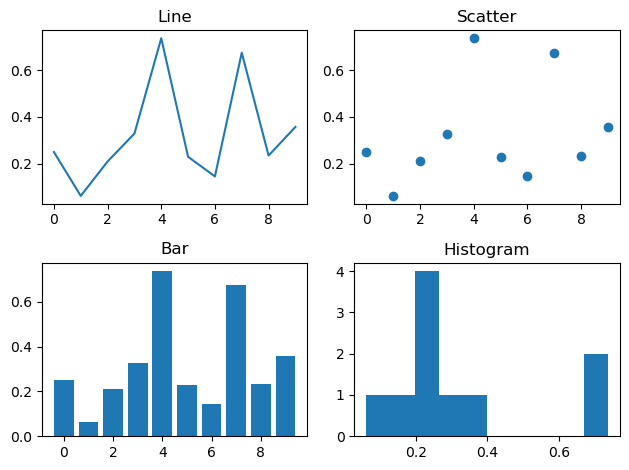

In [27]:

f = np.random.rand(10)

plt.figure()

plt.subplot(2,2,1)            # 2x2 grid, position 1
plt.plot(f)
plt.title("Line")

plt.subplot(2,2,2)            # position 2
plt.plot(f, 'o')
plt.title("Scatter")

plt.subplot(2,2,3)            # position 3
plt.bar(np.arange(len(f)), f)
plt.title("Bar")

plt.subplot(2,2,4)            # position 4
plt.hist(f)
plt.title("Histogram")

plt.tight_layout()
plt.show()



## 8. Fourier Transform with Python (NumPy & SciPy)

When analyzing signals (signal processing), it is often necessary to examine their frequency content or to filter out unwanted components.



### 8.1 Fast Fourier Transform (FFT) with NumPy

Because of the **Nyquist Theorem**, a signal sampled at a sufficient sampling rate can be fully represented by its **Discrete Fourier Transform (DFT)**.

The **Fast Fourier Transform (FFT)** is an efficient algorithm to compute the **Discrete Fourier Transform (DFT)**.  

Key points:

- `np.fft.fft(signal)` → this is the **Fourier Transform function** in NumPy.  
  - **Input:** a signal in the **time domain** (values over time).  
  - **Output:** the same signal in the **frequency domain** (Fourier coefficients, complex numbers).  
  - What we usually care about is the **magnitude** (`np.abs(...)`), which tells us **how strong each frequency is** in the signal.  
  - Intuitively: this creates the **y-axis (magnitude spectrum)** for the FFT output.


- `np.fft.fftfreq(n, d)` → gives the **frequency values (in Hz)** for each FFT coefficient.  
  - `n` = number of samples in your signal.  
  - `d` = time between samples (sampling interval, e.g. `1/Fs`).  
  - Intuitively: this creates the **x-axis (frequency values)** for the FFT output.


In [28]:

import numpy as np
import matplotlib.pyplot as plt

# --- Sampling parameters ---
Fs = 500                      # sampling rate (Hz)
t = np.arange(0, 1, 1/Fs)     # time vector: 0 to 1 second with step 1/Fs

# --- Create a test signal: 50 Hz + 120 Hz + random noise ---
x = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t) + 0.3*np.random.randn(len(t))           
    # 50 Hz sine wave      # add 120 Hz sine wave       # add random noise
                           # (smaller amplitude)   

# --- Perform FFT ---
ft = np.fft.fft(x)                       # FFT result (complex numbers)
magnitude = np.abs(ft)                   # magnitude (how "strong" each frequency is)
freqs = np.fft.fftfreq(len(ft), d=1/Fs)  # Frequency (Hz)


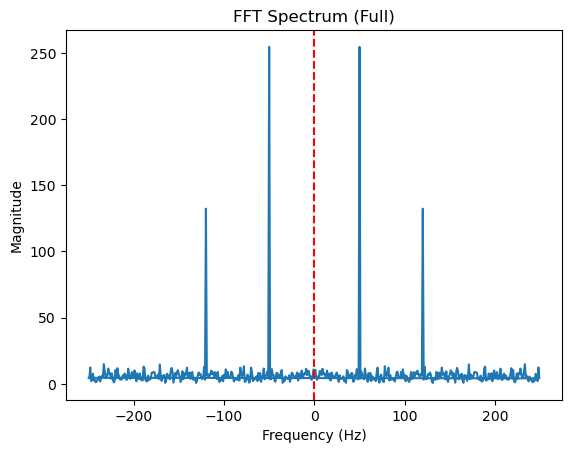

In [29]:

# Plot full spectrum (positive and negative)
plt.figure()
plt.plot(freqs, magnitude)
plt.axvline(x=0, color='r', linestyle='--', label='0 Hz')  # vertical line at x=0
plt.title("FFT Spectrum (Full)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


- When we do an FFT of a real signal (like sound or sensor data),

- The plot shows two sides: one with positive frequencies and one with negative frequencies.

- The negative side is just a mirror copy of the positive side.

- They look the same because real signals don’t need extra info from the negative side, it’s redundant.

More information about Fourier Transform, please refer to:

- https://www.youtube.com/watch?v=spUNpyF58BY

- https://www.khanacademy.org/science/electrical-engineering/ee-signals/ee-fourier-series/v/ee-fourier-series-intro


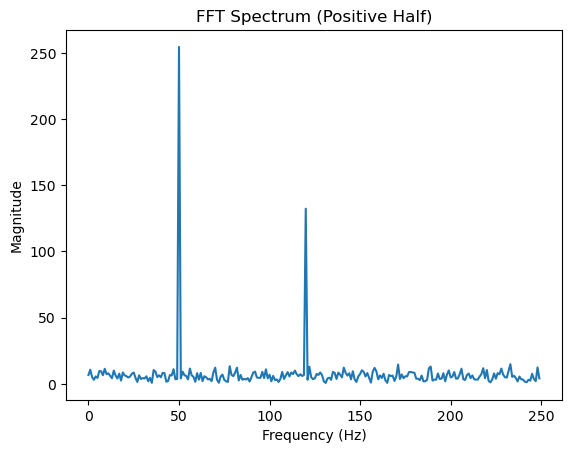

In [30]:

# Plot only positive half
plt.figure()
plt.plot(freqs[:len(freqs)//2], magnitude[:len(freqs)//2])   # //: floor division (always rounds down, e.g. 7//2 = 3)
plt.title("FFT Spectrum (Positive Half)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


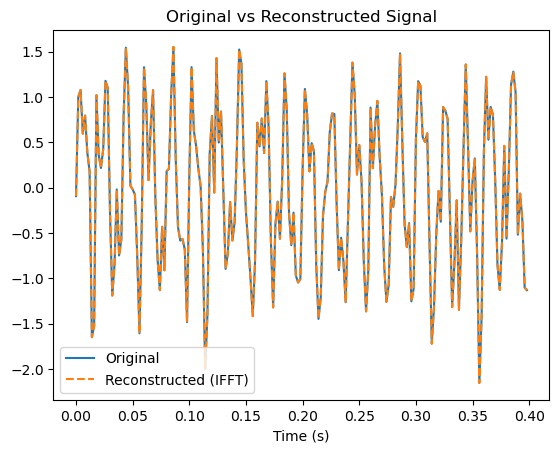

In [31]:
# Inverse FFT (reconstruction)
x_rec = np.fft.ifft(ft).real

plt.figure()
plt.plot(t[:200], x[:200], label="Original")
plt.plot(t[:200], x_rec[:200], "--", label="Reconstructed (IFFT)")
plt.title("Original vs Reconstructed Signal")
plt.xlabel("Time (s)")
plt.legend()
plt.show()


### 8.2 Filtering with SciPy

Our signal is a mixture of **50 Hz + 120 Hz + noise**.  
We can design filters to isolate different components:

- **Low-pass (<60 Hz)** → keeps the 50 Hz sinusoid  
- **High-pass (>110 Hz)** → keeps the 120 Hz sinusoid  
- **Band-pass (40–130 Hz)** → keeps both 50 Hz and 120 Hz  


In [32]:

from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# Sampling and signal (reuse from 8.1)
Fs = 500
t = np.arange(0, 1, 1/Fs)
x = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t) + 0.3*np.random.randn(len(t))

Nshow = 200   # number of samples to display


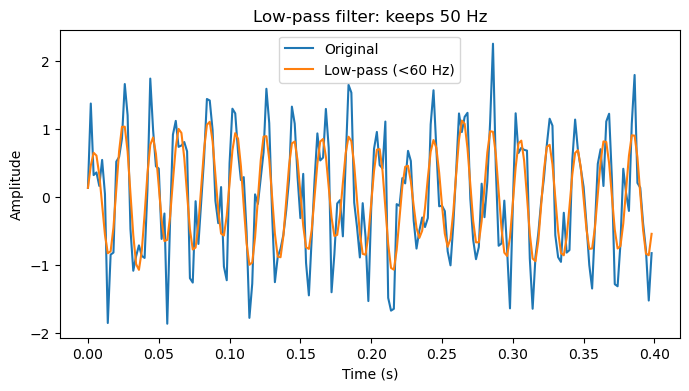

In [33]:

# --- Low-pass filter (<60 Hz) to isolate ~50 Hz ---
b_lp, a_lp = signal.butter(4, 60, fs=Fs, btype="low")
y_lp = signal.filtfilt(b_lp, a_lp, x)

plt.figure(figsize=(8,4))
plt.plot(t[:Nshow], x[:Nshow], label="Original")
plt.plot(t[:Nshow], y_lp[:Nshow], label="Low-pass (<60 Hz)")
plt.title("Low-pass filter: keeps 50 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


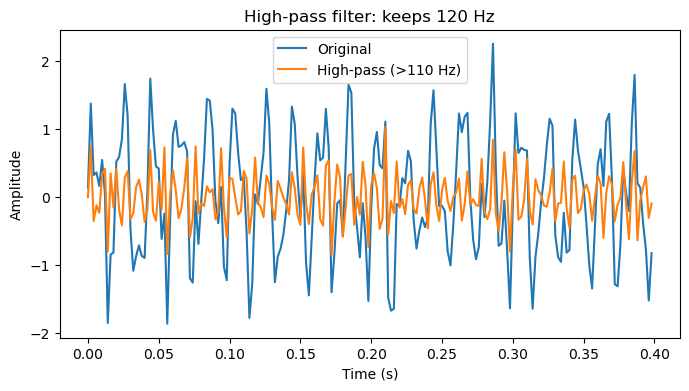

In [34]:

# --- High-pass filter (>110 Hz) to isolate ~120 Hz ---
b_hp, a_hp = signal.butter(4, 110, fs=Fs, btype="high")
y_hp = signal.filtfilt(b_hp, a_hp, x)

plt.figure(figsize=(8,4))
plt.plot(t[:Nshow], x[:Nshow], label="Original")
plt.plot(t[:Nshow], y_hp[:Nshow], label="High-pass (>110 Hz)")
plt.title("High-pass filter: keeps 120 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


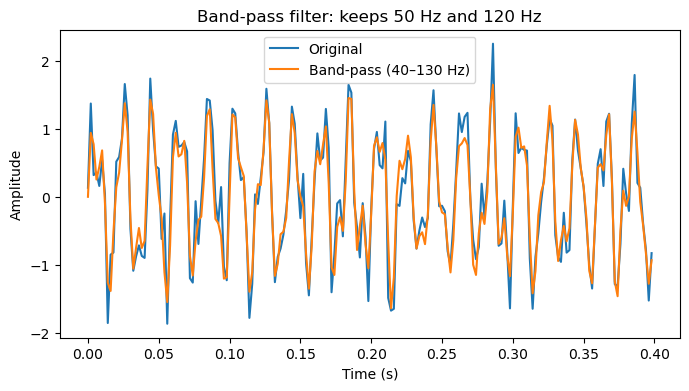

In [35]:

# --- Band-pass filter (40–130 Hz) to keep both 50 Hz and 120 Hz ---
b_bp, a_bp = signal.butter(4, [40, 130], fs=Fs, btype="band")
y_bp = signal.filtfilt(b_bp, a_bp, x)

plt.figure(figsize=(8,4))
plt.plot(t[:Nshow], x[:Nshow], label="Original")
plt.plot(t[:Nshow], y_bp[:Nshow], label="Band-pass (40–130 Hz)")
plt.title("Band-pass filter: keeps 50 Hz and 120 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


### Try it yourself
Generate a signal that mixes a 20 Hz and a 200 Hz sine wave, sampled at `Fs = 500` Hz.
1. Compute its FFT and plot the positive-frequency magnitude spectrum.
2. Design a band-pass filter that isolates the 20 Hz component and plot the filtered signal.

*Note: since Fs = 500 Hz, the Nyquist frequency is 250 Hz - any component at or above that will alias. Keep this in mind if you change Fs or the signal frequencies.*


In [36]:
# Your code here


## 9. Using AI Tools to Assist with Coding

AI coding assistants (ChatGPT, Claude, GitHub Copilot, Gemini, etc.) can be genuinely useful for this course, but only if you use them in a way that still builds your own understanding. This section gives some concrete, practical tips.

**Before anything else: check your syllabus.** While AI coding assistance is allowed for homework completion, make sure you're disclosing your usage as directed. 


### 9.1 What AI tools are good at (in a course like BIOINF 580)

- **Explaining error messages.** Pasting a traceback and asking "what does this error mean and why is it happening?" is often faster than searching StackOverflow, and the explanation usually generalizes.
- **Explaining unfamiliar code or functions.** If you see `np.fft.fftfreq(n, d)` for the first time, asking an AI to explain what each argument does (and then checking against the [official docs](https://numpy.org/doc/stable/reference/generated/numpy.fft.fftfreq.html)) is a solid way to learn.
- **Boilerplate you already understand conceptually.** E.g., "write a matplotlib subplot grid with 2 rows and 3 columns" - a mechanical task where you know *what* you want, just not the exact syntax.
- **Rubber-duck debugging.** Describing your code and what it *should* do vs. what it's *actually* doing to an AI (like explaining it to a person) often helps you spot the bug yourself.
- **Generating test cases.** Asking "give me 5 edge cases I should test this function against" is a good habit builder.


### 9.2 What to watch out for

- **Hallucinated functions and parameters.** AI models sometimes invent plausible-looking but nonexistent function names or arguments (e.g., a `scipy.signal.butter` parameter that doesn't actually exist). **Always cross-check against the official documentation** before trusting a suggestion you haven't seen before.
- **Outdated syntax.** Libraries change. An AI trained on older code may suggest a deprecated pandas method or an old matplotlib API. If code doesn't run, check the current docs for the version you have installed (`pd.__version__`, etc.).
- **Silently wrong math.** This is the most dangerous failure mode for a bioinformatics/signal-processing course: code that *runs without errors* but computes the wrong thing (e.g., an off-by-one in a filter's cutoff, a wrong axis in an FFT, a transposed matrix). AI-generated code is not exempt from this - **test it against a case where you know the right answer.**
- **Overly confident explanations.** AI assistants rarely say "I'm not sure." If an explanation doesn't quite make sense, or contradicts the docs/textbook, trust the primary source over the AI.
- **Losing the learning opportunity.** If you ask an AI to just "solve the lab for you," you'll finish faster today and struggle more tomorrow. Use it to get *unstuck*, not to skip the thinking.


### 9.3 Writing effective prompts

Vague prompts get vague (or wrong) answers. Compare:

> "My code doesn't work, fix it."

> "This Python function is supposed to band-pass filter a signal between 40–130 Hz using `scipy.signal.butter`, but the output looks unfiltered. Here's the code and the error/plot I'm getting: `[paste code + traceback or describe the plot]`. What could be wrong?"

A good prompt usually includes:
1. **What you're trying to accomplish** (the goal, not just the symptom)
2. **The relevant code** (not the whole notebook, just the function/cell in question)
3. **What you expected vs. what actually happened** (error text, wrong output, unexpected plot shape, etc.)
4. **Any constraints** (e.g., "must use only NumPy, no SciPy" if that's a requirement)

The more specific and self-contained your prompt, the more useful (and checkable) the answer will be.


### 9.4 A worked example: using AI to debug, then verifying it yourself

Below is a deliberately buggy function. This is the kind of thing you might paste into an AI assistant along with the error you see.


In [ ]:
# Buggy version: intended to band-pass filter a signal between low_hz and high_hz
from scipy import signal
import numpy as np

def bandpass_filter(x, low_hz, high_hz, fs, order=4):
    # BUG: forgot to normalize frequencies by the Nyquist frequency
    b, a = signal.butter(order, [low_hz, high_hz], btype="band", fs=fs)
    return signal.filtfilt(b, a, x)

# Try it (this particular call happens to work because fs is passed to butter,
# but imagine a version where fs is omitted, a very common copy-paste bug):
Fs = 500
t = np.arange(0, 1, 1/Fs)
x = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)
y = bandpass_filter(x, 40, 130, Fs)
print("Output length matches input:", len(y) == len(x))


Output length matches input: True


If you pasted this into an AI assistant with the prompt *"why does removing the `fs=fs` argument from `signal.butter` break my filter?"*, a good answer would explain that `scipy.signal.butter` expects frequencies **normalized to the Nyquist frequency** (i.e., as a fraction of `fs/2`) unless you explicitly pass `fs=fs`. That's a genuinely useful, checkable explanation - and you can verify it yourself in the [`scipy.signal.butter` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html).

**The verification step is the part you should never skip.** Below, we check the fixed function against a case where we know the right answer: a filtered signal should keep the frequencies inside the passband and suppress the ones outside it.


In [40]:
# Verify correctness against a known case: a 50 Hz + 120 Hz mixture,
# band-passed to 40-130 Hz should preserve BOTH tones' amplitude.
freqs = np.fft.fftfreq(len(y), d=1/Fs)
mag = np.abs(np.fft.fft(y))

# Find magnitude near 50 Hz and near 120 Hz
idx_50 = np.argmin(np.abs(freqs - 50))
idx_120 = np.argmin(np.abs(freqs - 120))
idx_300 = np.argmin(np.abs(freqs - 300))  # outside any input signal, should be ~0

print(f"Magnitude near 50 Hz:  {mag[idx_50]:.1f}  (should be large)")
print(f"Magnitude near 120 Hz: {mag[idx_120]:.1f}  (should be large)")
print(f"Magnitude near 300 Hz: {mag[idx_300]:.2f}  (should be ~0, no such component exists)")


Magnitude near 50 Hz:  240.7  (should be large)
Magnitude near 120 Hz: 105.7  (should be large)
Magnitude near 300 Hz: 0.38  (should be ~0, no such component exists)


### 9.5 A quick checklist before you trust AI-generated code

- [ ] Did I read and understand every line, not just skim it?
- [ ] Did I check unfamiliar functions/arguments against the official documentation?
- [ ] Did I run it on a case where I already know the correct answer?
- [ ] Does the result make physical/mathematical sense (right shape, right units, right order of magnitude)?
- [ ] Have I checked the course's AI-use policy for this specific assignment?

If you can check all of these boxes, you're using the tool well, as an accelerant for learning (not a replacement for it).
